
## Goal of this notebook is to find the contigs from the mitochondrial chromosomes 
Important point to note is that we do not want to filter out the nuclear mitochondrial DNA segments. We found around 755 NUMTs in the human genome. Criteria:
1. Present in the blast table
2. Contains much higher sequencing coverage > 100 fold difference 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import matplotlib.lines as mlines
from Bio import SeqIO


In [2]:
# Read in the mitochondrial blast table 
mito_table = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/assigning-chromosomes/mitochrondria/hifiasm_041425_mito_blast.out", sep="\t",names=['qseqid','sseqid','pident','qcovs','length','gapopen','evalue','bitscore','mismatch'])
print("Mito Table:")
display(mito_table.head())
print(mito_table.shape)

# Read in the assembly table
assembly_table = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/041425-assembly/hifiasm-041425-assembly/deNovo_hifiHiCMode_hifiData_aggressivePurge3_kmer21_041325.asm.hic.p_ctg.fa.fai", sep="\t", names=['chrom','length','x','x1','x2']).iloc[:, :2]
print("\nAssembly Table:")
display(assembly_table.head())

# Read in the long_reads coverage table
coverage_table = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/coverage_long_read_hifiasm_041425_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
print("\nCoverage Table:")
display(coverage_table.head())

# # Read in the short_reads coverage table
# coverage_table = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/command-line-script/contig-coverage/1-allreads-coverage/coverage_short_read_hifiasm_041425_scaffolded_juiceBox_sorted_contig.tsv", sep="\t", names=['contig','start_pos','end_pos','coverage'])
# print("\nCoverage Table:")
# display(coverage_table.head())




Mito Table:


,qseqid,sseqid,pident,qcovs,length,gapopen,evalue,bitscore,mismatch
0,NC_020661.1,ptg000479l,98.490,100,16822,23,0.0,29639.0,215
1,NC_020661.1,ptg000479l,97.912,100,6802,33,0.0,11734.0,99
2,NC_020661.1,ptg000479l,98.837,100,1806,5,0.0,3214.0,16
3,NC_020661.1,ptg000479l,93.645,100,598,8,0.0,880.0,22
4,NC_020661.1,ptg000361l,98.473,100,16833,16,0.0,29636.0,210


(205, 9)

Assembly Table:


,chrom,length
0,ptg000001l,9045362
1,ptg000002l,62027076
2,ptg000003l,63333489
3,ptg000004l,54113450
4,ptg000005l,3681248



Coverage Table:


,contig,start_pos,end_pos,coverage
0,ptg000001l,0,9045362,25.409279
1,ptg000002l,0,62027076,40.907246
2,ptg000003l,0,63333489,41.353302
3,ptg000004l,0,54113450,40.079227
4,ptg000005l,0,3681248,73.527222


In [3]:
print("How many different contigs have been identified") 

mito_contigs = mito_table["sseqid"].unique()
len(mito_contigs)

How many different contigs have been identified


71

What is the length distribution of the mitochondrial contigs


(array([33.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,  1.,
         1.,  1.,  0.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  3.,  1.,  1.,  2.,  1.,  2.,  0.,  1.,  1.,  1.,  1.,
         0.,  0.,  0.,  1.,  0.,  2.,  1.,  0.,  0.,  0.,  3.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  0.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([1.05450000e+04, 1.13689911e+06, 2.26325322e+06, 3.38960733e+06,
        4.51596144e+06, 5.64231555e+06, 6.76866966e+06, 7.89502377e+06,
        9.02137788e+06, 1.01477320e+07, 1.12740861e+07, 1.24004402e+07,
        1.35267943e+07, 1.46531484e+07, 1.57795025e+07, 1.69058567e+07,
        1.80322108e+07, 1.91585649e+07, 2.02849190e+07, 2.14112731e+07,
        2.25376272e+07, 2.36639813e+07, 2.47903354e+07, 2.59166895e+07,
  

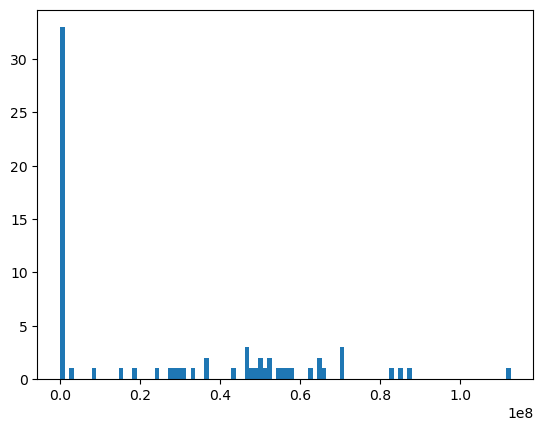

In [4]:
print("What is the length distribution of the mitochondrial contigs")
plot_mito_length = assembly_table[assembly_table["chrom"].isin(mito_contigs)]
plot_mito_length
plt.hist(plot_mito_length["length"],density=False, bins=100)

In [5]:
## Theoretical mitochondrial contigs because the mito chrom is about 16 kb
plot_mito_length[plot_mito_length["length"]<20000]

,chrom,length
450,ptg000451l,17433
454,ptg000455l,18669
455,ptg000456l,18609
484,ptg000485l,10545


In [6]:
plot_mito_length[plot_mito_length["length"]<20000]

,chrom,length
450,ptg000451l,17433
454,ptg000455l,18669
455,ptg000456l,18609
484,ptg000485l,10545


In [7]:
plot_mito_length[plot_mito_length["length"]<20000][["length"]]

,length
450,17433
454,18669
455,18609
484,10545


In [8]:
plot_mito_length[plot_mito_length["length"]<16798][["length"]]


,length
484,10545


(array([1., 0., 0., 0., 0., 0., 0., 0., 1., 2.]),
 array([10545. , 11357.4, 12169.8, 12982.2, 13794.6, 14607. , 15419.4,
        16231.8, 17044.2, 17856.6, 18669. ]),
 <BarContainer object of 10 artists>)

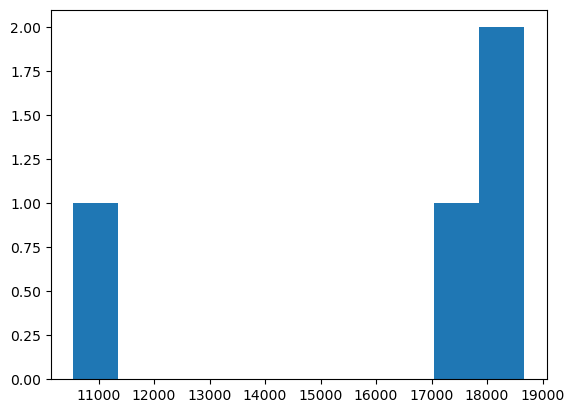

In [9]:
plt.hist(plot_mito_length[plot_mito_length["length"]<20000][["length"]]) # 16kb is the size of the mitochondrial chromosome size

(array([ 1.,  3.,  1.,  8., 11.,  4.,  2.,  0.,  1.,  1.,  1.]),
 array([10545.        , 14709.09090909, 18873.18181818, 23037.27272727,
        27201.36363636, 31365.45454545, 35529.54545455, 39693.63636364,
        43857.72727273, 48021.81818182, 52185.90909091, 56350.        ]),
 <BarContainer object of 11 artists>)

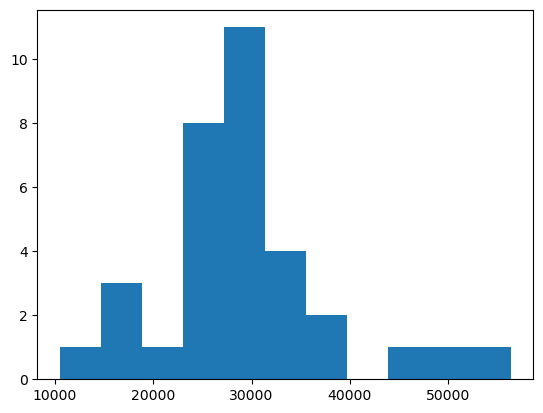

In [10]:
plt.hist(plot_mito_length[plot_mito_length["length"]<200000][["length"]], bins=11) # 16kb is the size of the mitochondrial chromosome size

(array([426.,  56.,  11.,   3.,   6.,   9.,   5.,   4.,   3.,   1.]),
 array([   1.6050525 ,  146.84613416,  292.08721582,  437.32829748,
         582.56937914,  727.8104608 ,  873.05154246, 1018.29262412,
        1163.53370578, 1308.77478744, 1454.0158691 ]),
 <BarContainer object of 10 artists>)

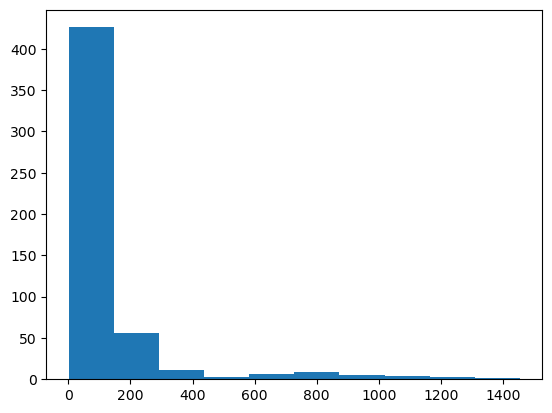

In [11]:
## Waiting for the coverage analysis to be done 
plt.hist(coverage_table["coverage"])

In [12]:
coverage_table.head()

,contig,start_pos,end_pos,coverage
0,ptg000001l,0,9045362,25.409279
1,ptg000002l,0,62027076,40.907246
2,ptg000003l,0,63333489,41.353302
3,ptg000004l,0,54113450,40.079227
4,ptg000005l,0,3681248,73.527222


In [14]:
alignment_plot_table = pd.merge(mito_table, assembly_table, left_on="sseqid", right_on="chrom", how="left")
alignment_plot_table = pd.merge(alignment_plot_table, coverage_table, left_on="sseqid", right_on="contig", how="left")
alignment_plot_table=alignment_plot_table.rename(columns={
    'length_x': 'alignment_length',
    'length_y': 'contig_length'
})
alignment_plot_table

,qseqid,sseqid,pident,qcovs,alignment_length,gapopen,evalue,bitscore,mismatch,chrom,contig_length,contig,start_pos,end_pos,coverage
0,NC_020661.1,ptg000479l,98.490,100,16822,23,0.000000e+00,29639.0,215,ptg000479l,25723,ptg000479l,0,25723,162.052719
1,NC_020661.1,ptg000479l,97.912,100,6802,33,0.000000e+00,11734.0,99,ptg000479l,25723,ptg000479l,0,25723,162.052719
2,NC_020661.1,ptg000479l,98.837,100,1806,5,0.000000e+00,3214.0,16,ptg000479l,25723,ptg000479l,0,25723,162.052719
3,NC_020661.1,ptg000479l,93.645,100,598,8,0.000000e+00,880.0,22,ptg000479l,25723,ptg000479l,0,25723,162.052719
4,NC_020661.1,ptg000361l,98.473,100,16833,16,0.000000e+00,29636.0,210,ptg000361l,48813,ptg000361l,0,48813,1272.056519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,NC_020661.1,ptg000060l,83.974,1,156,2,8.860000e-32,148.0,23,ptg000060l,55519876,ptg000060l,0,55519876,36.006779
201,NC_020661.1,ptg000103l,77.551,1,196,6,1.160000e-20,111.0,36,ptg000103l,70010223,ptg000103l,0,70010223,41.726177
202,NC_020661.1,ptg000019l,98.148,0,54,0,1.170000e-15,95.3,1,ptg000019l,65063595,ptg000019l,0,65063595,38.054993
203,NC_020661.1,ptg000070l,87.719,0,57,1,9.180000e-07,65.8,6,ptg000070l,33192476,ptg000070l,0,33192476,70.987381


In [15]:
print(alignment_plot_table.shape)
alignment_plot_table.head()

(205, 15)


,qseqid,sseqid,pident,qcovs,alignment_length,gapopen,evalue,bitscore,mismatch,chrom,contig_length,contig,start_pos,end_pos,coverage
0,NC_020661.1,ptg000479l,98.490,100,16822,23,0.0,29639.0,215,ptg000479l,25723,ptg000479l,0,25723,162.052719
1,NC_020661.1,ptg000479l,97.912,100,6802,33,0.0,11734.0,99,ptg000479l,25723,ptg000479l,0,25723,162.052719
2,NC_020661.1,ptg000479l,98.837,100,1806,5,0.0,3214.0,16,ptg000479l,25723,ptg000479l,0,25723,162.052719
3,NC_020661.1,ptg000479l,93.645,100,598,8,0.0,880.0,22,ptg000479l,25723,ptg000479l,0,25723,162.052719
4,NC_020661.1,ptg000361l,98.473,100,16833,16,0.0,29636.0,210,ptg000361l,48813,ptg000361l,0,48813,1272.056519


Text(0.5, 1.0, 'Mitochondrial chrom alignment vs coverage')

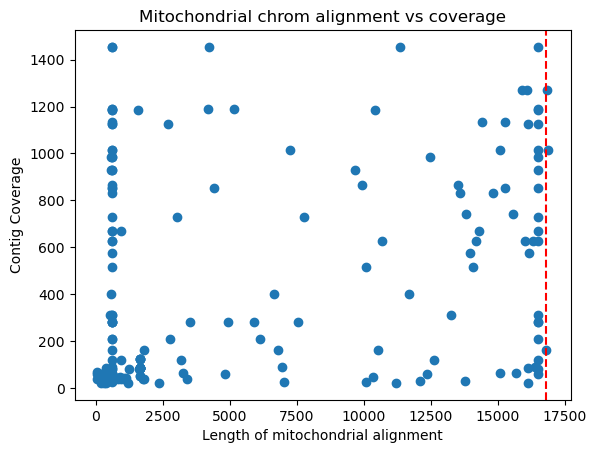

In [16]:
## Do a scatter plot of coverage and length and circle 
plt.scatter(alignment_plot_table["alignment_length"], alignment_plot_table["coverage"])
plt.axvline(x=16798, color='r', linestyle='--', linewidth=1.5)

# Add labels and title
plt.xlabel("Length of mitochondrial alignment")
plt.ylabel("Contig Coverage")
plt.title("Mitochondrial chrom alignment vs coverage")
## None of the alignment could be larger than mito chrom size anyways 

In [17]:
# Create collapsed dataframe (if not already done)
contig_df = alignment_plot_table.groupby('contig').agg({
    'alignment_length': 'sum',  # Total aligned length
    'pident': 'mean',
    'contig_length': 'first',  # Contig length (same for all rows)
    'coverage': 'first',  # Coverage (same for all rows)
    'chrom': 'first'
})
contig_df['alignment_percent'] = contig_df['alignment_length']/contig_df['contig_length'] * 100
contig_df

,alignment_length,pident,contig_length,coverage,chrom,alignment_percent
contig,,,,,,
ptg000002l,1405,93.259750,62027076,40.907246,ptg000002l,0.002265
ptg000010l,362,93.923000,18124704,47.676254,ptg000010l,0.001997
ptg000011l,1777,77.997000,54766377,40.712330,ptg000011l,0.003245
ptg000012l,2020,74.171500,49964018,41.134193,ptg000012l,0.004043
ptg000013l,586,92.321000,57838845,60.238144,ptg000013l,0.001013
...,...,...,...,...,...,...
ptg000455l,18947,96.780667,18669,64.010979,ptg000455l,101.489100
ptg000456l,18876,96.952333,18609,402.896179,ptg000456l,101.434790
ptg000478l,27947,95.441800,27402,931.252441,ptg000478l,101.988906


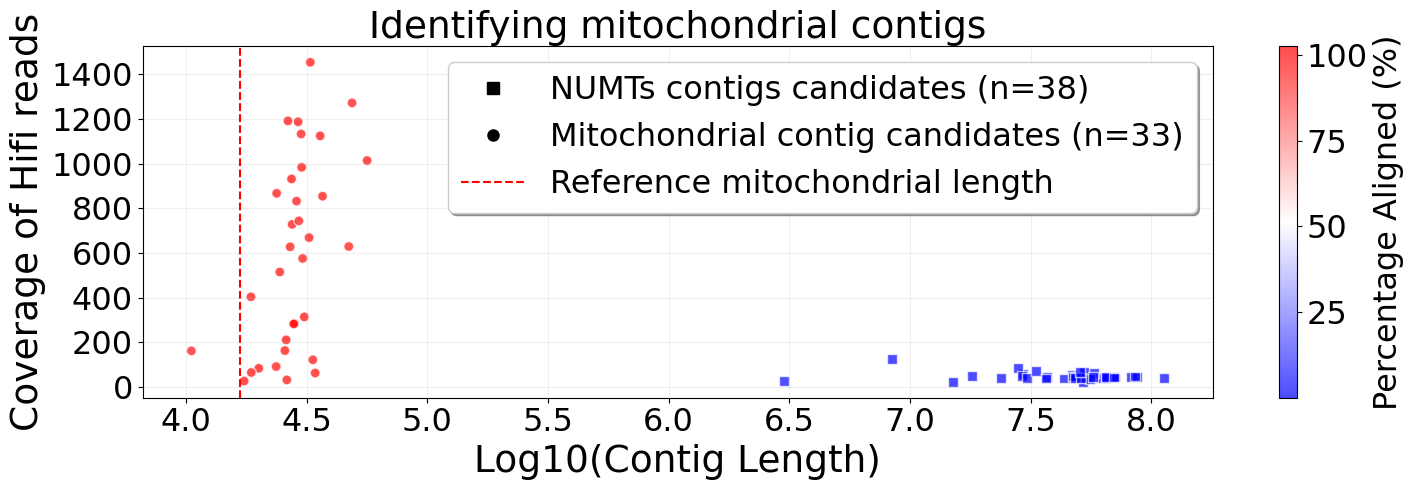

In [20]:
# Classification and visualization (with marker shapes)
threshold = 100000
contig_df['group'] = np.where(
    contig_df['contig_length'] >= threshold,
    'Contigs with NUMTs',
    "Mitochondrial contig candidates"
)

# Get the corresponding #
num_numts = len(contig_df[contig_df['group'] == "Contigs with NUMTs"])
num_mito = len(contig_df[contig_df['group'] =="Mitochondrial contig candidates"])

# Set global font sizes
title_fontsize = 27
axis_label_fontsize = 27
tick_fontsize = 23
legend_fontsize = 23
colorbar_fontsize = 23

# Custom legend handles (black markers with the correct shape)
legend_numts = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                             markersize=8, label=f"NUMTs contigs candidates (n={num_numts})")
legend_mito = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=8, label= f"Mitochondrial contig candidates (n={num_mito})")
legend_line = mlines.Line2D([], [], color='red', linestyle='--',
                            label='Reference mitochondrial length')

# Split data
above = contig_df[contig_df['group'] == 'Contigs with NUMTs']
below = contig_df[contig_df['group'] == "Mitochondrial contig candidates"]

# Get global color limits
vmin = contig_df['alignment_percent'].min()
vmax = contig_df['alignment_percent'].max()

plt.figure(figsize=(15, 5))

# Create scatter plots with different markers
sc1 = plt.scatter(
    x=np.log10(above['contig_length']),
    y=above['coverage'],
    c=above['alignment_percent'],
    s=50,
    marker='s',  # Square for NUMTs
    cmap='bwr',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,
    vmax=vmax,
)

sc2 = plt.scatter(
    x=np.log10(below['contig_length']),
    y=below['coverage'],
    c=below['alignment_percent'],
    s=50,
    marker='o',  # Circle for candidates
    cmap='bwr',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,
    vmax=vmax,
)

# Add reference line (Degu mitochondrial length)
plt.axvline(
    x=np.log10(16798),
    color='r',
    linestyle='--')

cbar = plt.colorbar(sc2)
cbar.set_label('Percentage Aligned (%)', fontsize=colorbar_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)  # Colorbar tick labels

# Formatting
plt.xlabel('Log10(Contig Length)', fontsize=axis_label_fontsize)
plt.ylabel('Coverage of Hifi reads', fontsize=axis_label_fontsize)
plt.title('Identifying mitochondrial contigs', fontsize=title_fontsize)

# Set tick label sizes
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Legend with custom font size
legend = plt.legend(handles=[legend_numts, legend_mito, legend_line], 
                   fontsize=legend_fontsize,
                   frameon=True,
                   fancybox=True,
                   shadow=True)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

AttributeError: PathCollection.set() got an unexpected keyword argument 'size'

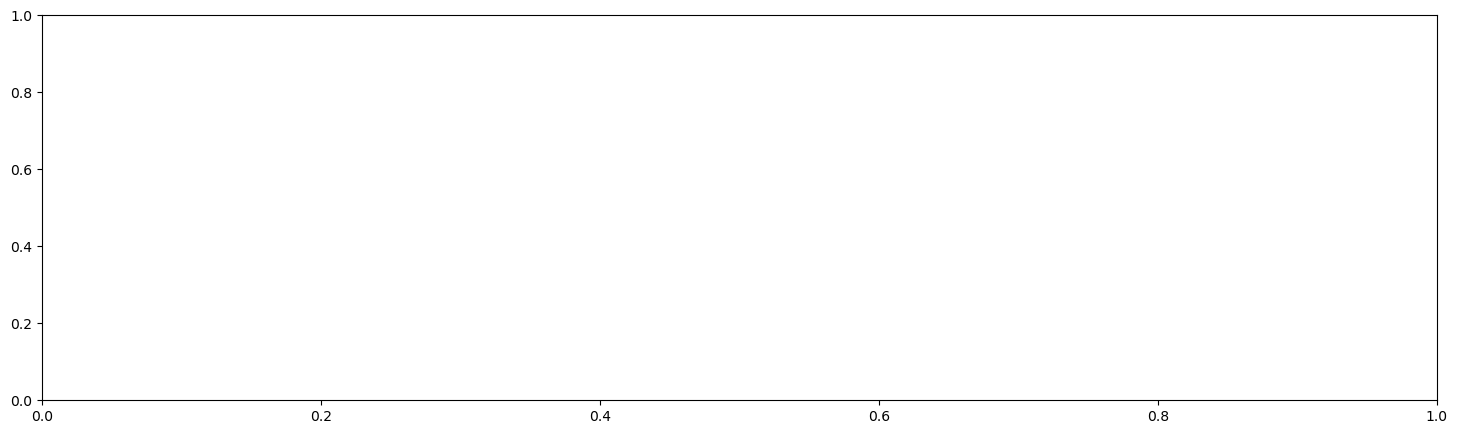

In [66]:
# Classification and visualization (with marker shapes)
threshold = 100000
contig_df['group'] = np.where(
    contig_df['contig_length'] >= threshold,
    'Contigs with NUMTs',
    "Mitochondrial contig candidates"
)

# Get the corresponding #
num_numts = len(contig_df[contig_df['group'] == "Contigs with NUMTs"])
num_mito = len(contig_df[contig_df['group'] =="Mitochondrial contig candidates"])

# Custom legend handles (black markers with the correct shape)
legend_numts = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                             markersize=8, label=f"NUMTs contigs candidates (n={num_numts})")
legend_mito = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=8, label= f"Mitochondrial contig candidates (n={num_mito})")
legend_line = mlines.Line2D([], [], color='red', linestyle='--',
                            label='Reference mitochondrial length')

# Split data
above = contig_df[contig_df['group'] == 'Contigs with NUMTs']
below = contig_df[contig_df['group'] == "Mitochondrial contig candidates"
]
# Get global color limits
vmin = contig_df['alignment_percent'].min()
vmax = contig_df['alignment_percent'].max()

plt.figure(figsize=(18, 5))

# Create scatter plots with different markers
sc1 = plt.scatter(
    x=np.log10(above['contig_length']),
    y=above['coverage'],
    c=above['alignment_percent'],
    s=50,
    marker='s',  # Square for NUMTs
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,  # Critical fix
    vmax=vmax,  # Critical fix
)

sc2 = plt.scatter(
    x=np.log10(below['contig_length']),
    y=below['coverage'],
    c=below['alignment_percent'],
    s=50,
    marker='o',  # Circle for candidates
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,  # Critical fix
    vmax=vmax,  # Critical fix
)

# Add reference line (Degu mitochondrial length)
plt.axvline(
    x=np.log10(16798),
    color='r',
    linestyle='--')

cbar = plt.colorbar(sc2)
cbar.set_label('Percentage Aligned (%)')

# Formatting
plt.xlabel('Log10(Contig Length)',size=27)
plt.ylabel('Coverage of Hifi reads',size=27)
plt.title('Contigs wtih mitochondrial alignment',size=27)
plt.legend(handles=[legend_numts, legend_mito, legend_line])
# plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
print(below.shape)
print(above.shape)

(33, 7)
(38, 7)


In [17]:
below.to_csv("mito_contigs.txt", sep="\t")

In [18]:
## Merge the information back to the alignments 
alignment_plot_table_final = alignment_plot_table.merge( contig_df["group"], left_on="sseqid", right_index=True, how="left")
alignment_plot_table_final

,qseqid,sseqid,pident,qcovs,alignment_length,gapopen,evalue,bitscore,mismatch,chrom,contig_length,contig,start_pos,end_pos,coverage,group
0,NC_020661.1,ptg000479l,98.490,100,16822,23,0.000000e+00,29639.0,215,ptg000479l,25723,ptg000479l,0,25723,162.052719,Mitochondrial contig candidates
1,NC_020661.1,ptg000479l,97.912,100,6802,33,0.000000e+00,11734.0,99,ptg000479l,25723,ptg000479l,0,25723,162.052719,Mitochondrial contig candidates
2,NC_020661.1,ptg000479l,98.837,100,1806,5,0.000000e+00,3214.0,16,ptg000479l,25723,ptg000479l,0,25723,162.052719,Mitochondrial contig candidates
3,NC_020661.1,ptg000479l,93.645,100,598,8,0.000000e+00,880.0,22,ptg000479l,25723,ptg000479l,0,25723,162.052719,Mitochondrial contig candidates
4,NC_020661.1,ptg000361l,98.473,100,16833,16,0.000000e+00,29636.0,210,ptg000361l,48813,ptg000361l,0,48813,1272.056519,Mitochondrial contig candidates
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,NC_020661.1,ptg000060l,83.974,1,156,2,8.860000e-32,148.0,23,ptg000060l,55519876,ptg000060l,0,55519876,36.006779,Contigs with NUMTs
201,NC_020661.1,ptg000103l,77.551,1,196,6,1.160000e-20,111.0,36,ptg000103l,70010223,ptg000103l,0,70010223,41.726177,Contigs with NUMTs
202,NC_020661.1,ptg000019l,98.148,0,54,0,1.170000e-15,95.3,1,ptg000019l,65063595,ptg000019l,0,65063595,38.054993,Contigs with NUMTs
203,NC_020661.1,ptg000070l,87.719,0,57,1,9.180000e-07,65.8,6,ptg000070l,33192476,ptg000070l,0,33192476,70.987381,Contigs with NUMTs


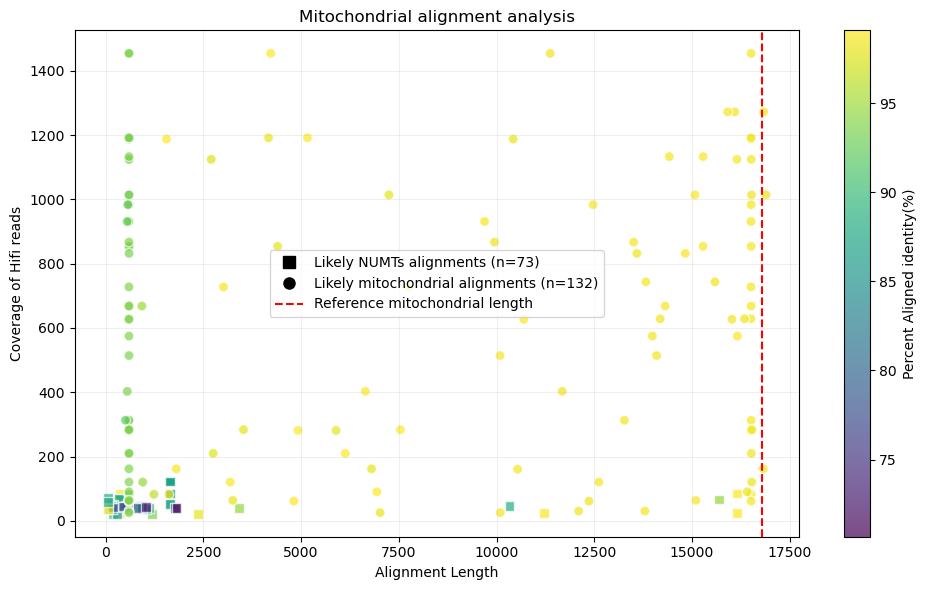

In [19]:
# Get the corresponding alignements?
num_numts = len(alignment_plot_table_final[alignment_plot_table_final['group'] == "Contigs with NUMTs"])
num_mito = len(alignment_plot_table_final[alignment_plot_table_final['group'] =="Mitochondrial contig candidates"])

# Custom legend handles (black markers with the correct shape)
legend_numts = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                             markersize=8, label=f'Likely NUMTs alignments (n={num_numts})')
legend_mito = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=8, label=f"Likely mitochondrial alignments (n={num_mito})")
legend_line = mlines.Line2D([], [], color='red', linestyle='--',
                            label='Reference mitochondrial length')

# # Split data
above = alignment_plot_table_final[alignment_plot_table_final['group'] == 'Contigs with NUMTs']
below = alignment_plot_table_final[alignment_plot_table_final['group'] == 'Mitochondrial contig candidates']
# Get global color limits
vmin = alignment_plot_table_final['pident'].min()
vmax = alignment_plot_table_final['pident'].max()

plt.figure(figsize=(10, 6))

# Create scatter plots with different markers
sc1 = plt.scatter(
    x=above['alignment_length'],
    y=above['coverage'],
    c=above['pident'],
    s=50,
    marker='s',  # Square for NUMTs
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,  # Critical fix
    vmax=vmax,  # Critical fix
)

sc2 = plt.scatter(
    x=below['alignment_length'],
    y=below['coverage'],
    c=below['pident'],
    s=50,
    marker='o',  # Circle for candidates
    cmap='viridis',
    alpha=0.7,
    edgecolor='w',
    vmin=vmin,  # Critical fix
    vmax=vmax,  # Critical fix
)

# Add reference line (Degu mitochondrial length)
plt.axvline(
    x=16798,
    color='r',
    linestyle='--')

cbar = plt.colorbar(sc2)
cbar.set_label('Percent Aligned identity(%)')

# # Formatting
plt.xlabel('Alignment Length')
plt.ylabel('Coverage of Hifi reads')
plt.title('Mitochondrial alignment analysis')
plt.legend(handles=[legend_numts, legend_mito, legend_line])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [21]:
with open("mito_contigs_041425.txt") as f:
    contigs_to_remove = set(line.split()[0] for line in f)

contigs_to_remove=list(contigs_to_remove)
exclude=contigs_to_remove

In [22]:
# Process FASTA and write output
with open('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/0414250-assembly/hifiasm-041425-assembly/deNovo_hifiHiCMode_hifiData_aggressivePurge3_kmer21_041325.asm.hic.p_ctg.fa') as fin, open('/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/data/denovo_OctDegus_genome/0414250-assembly/hifiasm-041425-assembly-mitoFiltered/genome_chrom.fasta', 'w') as fout:
    write_contig = False
    for line in fin:
        if line.startswith('>'):
            # Extract contig name from header (after '>' and before first space)
            contig_name = line[1:].split(maxsplit=1)[0].strip()
            write_contig = contig_name not in exclude
        if write_contig:
            fout.write(line)

In [23]:
contigs_to_remove

['ptg000306l',
 'ptg000390l',
 'ptg000393l',
 'ptg000456l',
 'ptg000324l',
 'ptg000428l',
 'ptg000317l',
 'ptg000394l',
 'ptg000361l',
 'ptg000485l',
 'contig',
 'ptg000346l',
 'ptg000365l',
 'ptg000451l',
 'ptg000339l',
 'ptg000335l',
 'ptg000367l',
 'ptg000370l',
 'ptg000415l',
 'ptg000373l',
 'ptg000455l',
 'ptg000351l',
 'ptg000293l',
 'ptg000478l',
 'ptg000392l',
 'ptg000391l',
 'ptg000354l',
 'ptg000372l',
 'ptg000479l',
 'ptg000369l',
 'ptg000295l',
 'ptg000401l',
 'ptg000371l',
 'ptg000334l']